# Advanced Programme in Deep Learning (Foundations and Applications)
## A Program by IISc and TalentSprint

## Support Vector Machine - Regression (SVR)

Support Vector Regression is a supervised learning algorithm that is used to predict discrete values. Support Vector Regression uses the same principle as the SVMs. The basic idea behind SVR is to find the best fit line. In SVR, the best fit line is the hyperplane that has the maximum number of points.


To use SVMs for regression instead of classification, the trick is to reverse the objective: instead of trying to fit the largest possible street between two classes while limiting
margin violations, SVM Regression tries to fit as many instances as possible
on the street while limiting margin violations (i.e., instances off the street). The width of the street is controlled by a hyperparameter, ε

![Image](https://www.saedsayad.com/images/SVR_2.png)

### Introduction

The problem that we are going to solve here is that given a set of features that describe a house in Boston, our machine learning model must predict the house price.

Following are the details of each feature/attribute of the given dataset.

In the dataset, each row describes a boston town or suburb. There are 506 rows and 13 attributes (features) with a target column MEDV (price).

### Dataset Description

The Boston House Price Dataset involves the prediction of a house price in thousands of dollars given details of the house and its neighborhood.

The dataset contains 506 rows and 14 columns. It consists of price of houses in various locations in Boston. Along with price, the dataset also provides information such as :

* CRIM - per capita crime rate by town.
* ZN - proportion of residential land zoned for lots over 25,000 sq.ft.
* INDUS - proportion of non-retail business acres per town.
* CHAS- Charles River dummy variable (= 1 if tract bounds river; 0 otherwise).
* NOX - nitrogen oxides concentration (parts per 10 million).
* RM - average number of rooms per dwelling.
* AGE - proportion of owner-occupied units built prior to 1940.
* DIS - weighted mean of distances to five Boston employment centres.
* RAD - index of accessibility to radial highways.
* TAX - full-value property-tax rate per $10,000$.
* PTRATIO - pupil-teacher ratio by town.
* B - 1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town.
* LSTAT - Percentage of lower status of the population
* MEDV (price) - Median value of owner-occupied homes in $1000s - target column


In [ ]:
#@title Run the cell to download the dataset
import warnings
warnings.filterwarnings("ignore")
!wget https://cdn.iisc.talentsprint.com/DLFA/Experiment_related_data/Housing_data.csv

### Importing required packages

In [ ]:
import pandas as pd
import numpy as np        # basic library to work with arrays
import seaborn as sns     # library for statistical data visualization
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

#### Loading the Boston dataset

In [ ]:
boston_data = pd.read_csv("Housing_data.csv")
boston_data.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [ ]:
# Check the shape of dataframe
boston_data.shape

(506, 14)

#### Check for missing values


In [ ]:
# Check for missing values
boston_data.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

There is no missing values in the dataset.



In [ ]:
# Viewing the data statistics
boston_data.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [ ]:
# Finding out the correlation between the features
corr = boston_data.corr()
corr.shape

(14, 14)

#### Visualization of Correlation Matrix

From the below matrix, we observe that the highly correlated features has the correlation value close to 1.

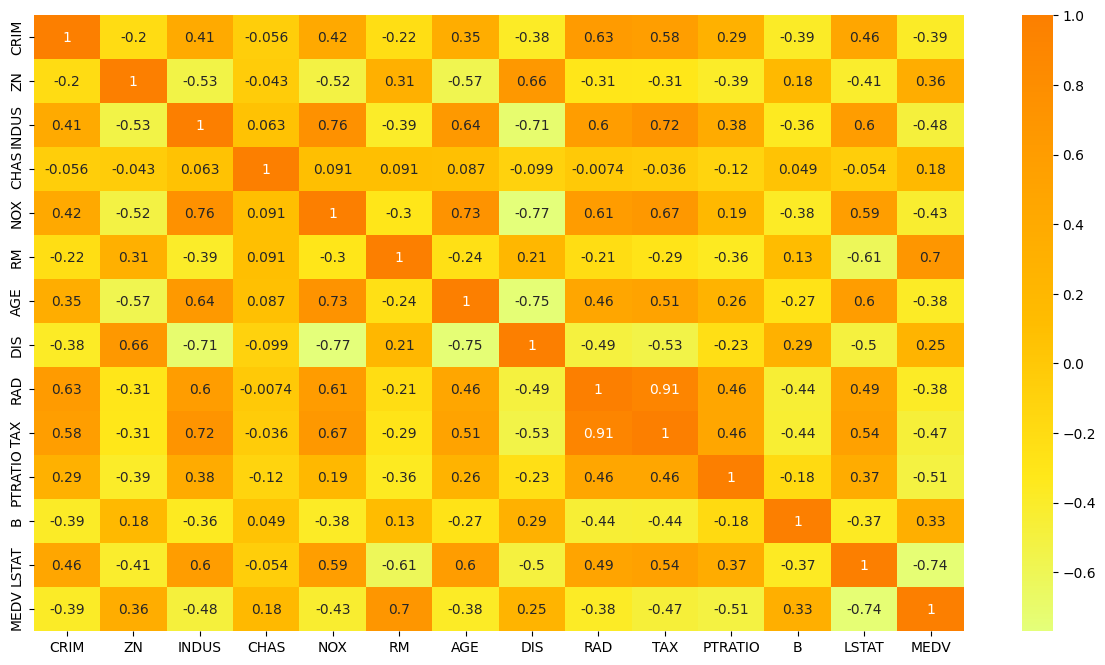

In [ ]:
# Plotting the heatmap of correlation between features
plt.figure(figsize=(15,8))
sns.heatmap(corr, cmap = 'Wistia', annot= True);

In [ ]:
# Spliting target variable and independent variables
X = boston_data.drop(['MEDV'], axis = 1).values # Independent features
y = boston_data['MEDV'].values # Dependent or target feature

In [ ]:
# Reshape the target variable as the MinMaxScaler expects 2D array
y = y.reshape(len(y), 1)

### Normalizing the data

For the above dataset you can observe that the ranges of different continuous variables are different. This is actually problematic. Therefore, we perform normalization for continuous variable.
  
The goal of normalization is to change the values of numeric columns in the dataset to a common scale without distorting differences in the ranges of values. We normalize the data to bring all the variables to the same range.


In [ ]:
sc = MinMaxScaler()
X = sc.fit_transform(X)
y = sc.fit_transform(y)

### Split the dataset into train and test sets

In [ ]:
# Splitting to training and testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

### Fit the SVM Regressor

#### Train the model using 'linear' kernel

**Note:** Refer to the following [link](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVR.html) for sklearn support vector regressor

In [ ]:
# Import SVM Regressor
from sklearn.svm import SVR

# Create a SVM Regressor using 'linear' kernel
linear_regressor = SVR(kernel='linear')

# Train the linear model using the training sets
linear_regressor.fit(X_train, y_train)

# Model prediction on train data using 'linear' kernel
y_pred_linear = linear_regressor.predict(X_train)
y_test_pred_linear = linear_regressor.predict(X_test)

#### Visualization of Actual vs Predicted prices (Linear Kernel)

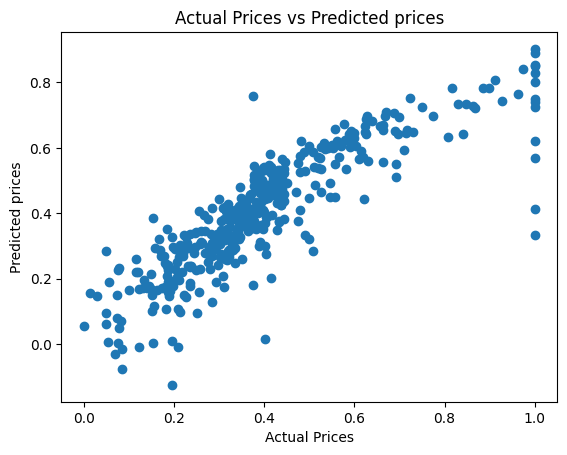

In [ ]:
# Visualizing the differences between actual prices and predicted values
plt.scatter(y_train, y_pred_linear)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted prices")
plt.title("Actual Prices vs Predicted prices")
plt.show()

#### Model Evaluation



**RMSE:** Root mean squared error (RMSE) is the square root of the mean of the square of all of the error. RMSE is a way to measure the accuracy, but only to compare prediction errors of different models or model configurations for a particular variable and not between variables, as it is scale-dependent. We compute Root Mean Square Error using formula.

$RMSE = \frac{1}{n} \sum_{i=1}^{n} ({S_i} − O_{i})^2$


where $O_i$ are the observations, $S_i$ predicted values of a variable, and 'n'
the number of observations available for analysis.





In [ ]:
# Predicting Test data with the linear model
y_test_pred_linear = linear_regressor.predict(X_test)

In [ ]:
# Model Evaluation
R_square = r2_score(y_test, y_test_pred_linear)
print('R square on SVR Linear Kernel:', R_square)

print('Root Mean Square Error on SVR Linear Kernel:',np.sqrt(mean_squared_error(y_test, y_test_pred_linear)))

R square on SVR Linear Kernel: 0.647475498837324
Root Mean Square Error on SVR Linear Kernel: 0.11298848477755706


The R square value denotes the accuracy of the model. As the accuracy of the model increases, the R square value reaches close to 1.

#### Train the model using 'rbf' kernel

**Note:** For more details on RBF kernel refer to the following [link](https://colab.research.google.com/drive/1VsV_5epYUBEtl9RQ36-ZbUr-XQZFKhNL)

In [ ]:
# Create a SVM Regressor using 'rbf' kernel
rbf_regressor = SVR(kernel='rbf')

# Train the model using the training sets
rbf_regressor.fit(X_train, y_train);

The follwing are the details of the parameters used in the SVM Regressor:

C : float, optional (default=1.0): The penalty parameter of the error term. It controls the trade off between smooth decision boundary and classifying the training points correctly.

kernel : string, optional (default='rbf’): kernel parameters selects the type of hyperplane used to separate the data. It must be one of 'linear', 'poly', 'rbf', 'sigmoid', 'precomputed’ or a callable.

degree : int, optional (default=3): Degree of the polynomial kernel function (‘poly’). Ignored by all other kernels.

gamma : float, optional (default='auto’): It is for non linear hyperplanes. The higher the gamma value it tries to exactly fit the training data set. Current default is 'auto' which uses 1 / n_features.

coef0 : float, optional (default=0.0): Independent term in kernel function. It is only significant in 'poly' and 'sigmoid'.

shrinking : boolean, optional (default=True): Whether to use the shrinking heuristic.

In [ ]:
# Model prediction on train data
y_pred_rbf = rbf_regressor.predict(X_train)

#### Visualization of Actual vs Predicted prices (RBF Kernel)





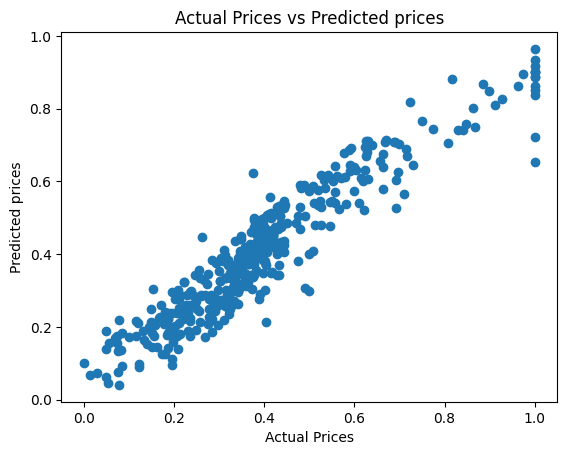

In [ ]:
# Visualizing the differences between actual prices and predicted values
plt.scatter(y_train, y_pred_rbf)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted prices")
plt.title("Actual Prices vs Predicted prices")
plt.show()

In [ ]:
# Predicting Test data with the model
y_test_pred_rbf = rbf_regressor.predict(X_test)

#### Model Evaluation for the test data


In [ ]:
# Model Evaluation
R_square = r2_score(y_test, y_test_pred_rbf)
print('R square on SVR RBF Kernel:', R_square)
print('Root Mean Square Error on SVR RBF Kernel:',np.sqrt(mean_squared_error(y_test, y_test_pred_rbf)))

R square on SVR RBF Kernel: 0.8262628386478895
Root Mean Square Error on SVR RBF Kernel: 0.07932058197393851
